# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

Dataset Wadai Khas Banjar adalah kumpulan gambar makanan tradisional 
khas Banjar, Kalimantan Selatan. Dataset terdiri dari 7 kelas:
bingka, bingka-berandam, hintalu-karuang, hula-hula, ipau, kikicak, talipuk.
Masing-masing kelas memiliki 200 gambar dengan ukuran 256x256 piksel.
Total dataset: 1400 gambar.
Sumber: Data primer yang dikumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

2026-06-04 13:36:51.729571: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-04 13:36:51.794305: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-04 13:36:53.467874: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries imported successfully


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
DATASET_PATH = '/home/yunus/Desktop/submission/dataset'
LABELS = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES = len(LABELS)

print(f"Jumlah kelas: {NUM_CLASSES}")
print(f"Label: {LABELS}")

# Hitung jumlah gambar per kelas
for label in LABELS:
    path = os.path.join(DATASET_PATH, label)
    count = len(os.listdir(path))
    print(f"  {label}: {count} gambar")

Jumlah kelas: 7
Label: ['bingka', 'bingka-berandam', 'hintalu-karuang', 'hula-hula', 'ipau', 'kikicak', 'talipuk']
  bingka: 200 gambar
  bingka-berandam: 200 gambar
  hintalu-karuang: 200 gambar
  hula-hula: 200 gambar
  ipau: 200 gambar
  kikicak: 200 gambar
  talipuk: 200 gambar


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

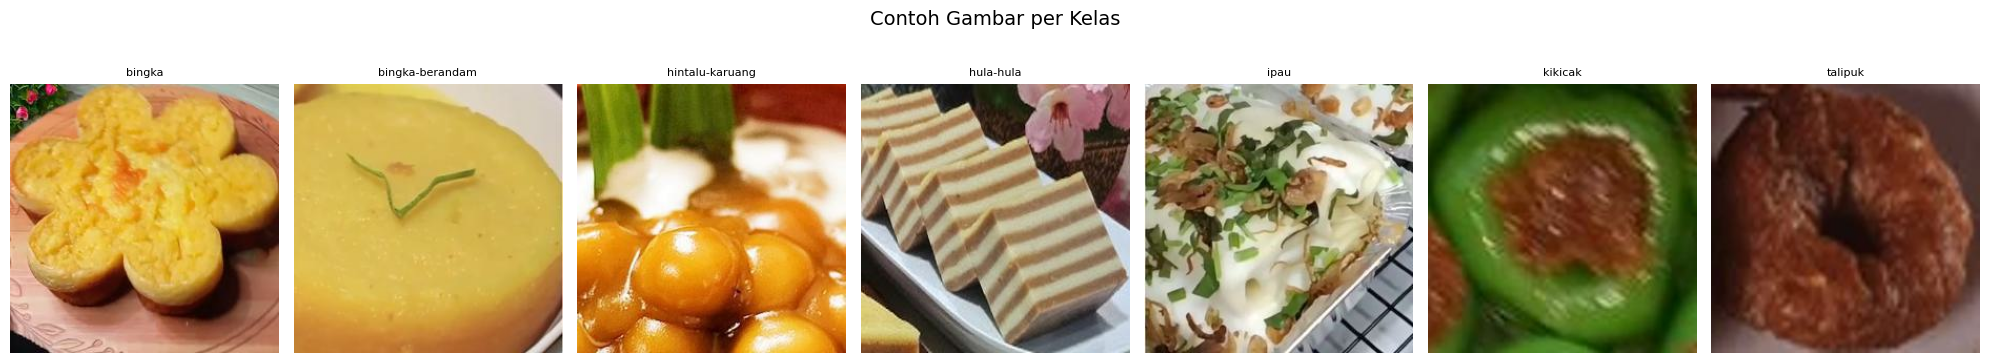

In [3]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))

for i, label in enumerate(LABELS):
    img_path = os.path.join(DATASET_PATH, label, os.listdir(os.path.join(DATASET_PATH, label))[0])
    img = load_img(img_path, target_size=(256, 256))
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=8)
    axes[i].axis('off')

plt.suptitle('Contoh Gambar per Kelas', fontsize=14)
plt.tight_layout()
plt.show()

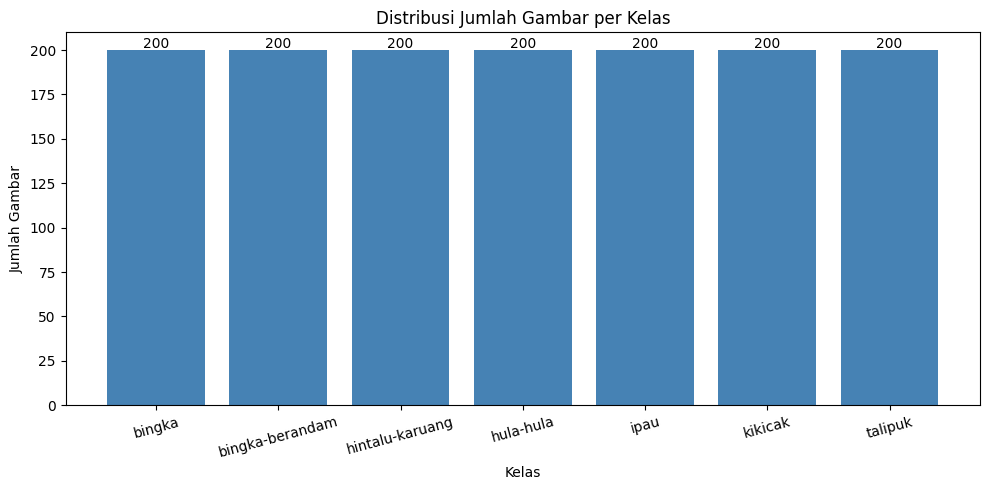

Total gambar: 1400
Dataset seimbang: True


In [4]:
counts = [len(os.listdir(os.path.join(DATASET_PATH, label))) for label in LABELS]

plt.figure(figsize=(10, 5))
plt.bar(LABELS, counts, color='steelblue')
plt.title('Distribusi Jumlah Gambar per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=15)
for i, v in enumerate(counts):
    plt.text(i, v + 1, str(v), ha='center')
plt.tight_layout()
plt.show()

print(f"Total gambar: {sum(counts)}")
print(f"Dataset seimbang: {len(set(counts)) == 1}")

In [5]:
sample_img_path = os.path.join(DATASET_PATH, LABELS[0], os.listdir(os.path.join(DATASET_PATH, LABELS[0]))[0])
sample_img = load_img(sample_img_path)
arr = img_to_array(sample_img)

print(f"Ukuran gambar sample: {sample_img.size}")
print(f"Shape array: {arr.shape}")
print(f"Nilai pixel min: {arr.min()}, max: {arr.max()}")

Ukuran gambar sample: (256, 256)
Shape array: (256, 256, 3)
Nilai pixel min: 0.0, max: 255.0


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
from sklearn.model_selection import train_test_split

IMG_SIZE = (256, 256)
images = []
labels = []

for idx, label in enumerate(LABELS):
    label_path = os.path.join(DATASET_PATH, label)
    for img_file in os.listdir(label_path):
        img = load_img(os.path.join(label_path, img_file), target_size=IMG_SIZE)
        img_array = img_to_array(img) / 255.0  # normalisasi
        images.append(img_array)
        labels.append(idx)

X = np.array(images)
y = np.array(labels)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Total data: {len(X)}")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}")
print(f"Nilai pixel setelah normalisasi - min: {X.min():.1f}, max: {X.max():.1f}")

Total data: 1400
X_train: (1120, 256, 256, 3), X_val: (280, 256, 256, 3)
y_train: (1120,), y_val: (280,)
Nilai pixel setelah normalisasi - min: 0.0, max: 1.0


In [7]:
SAVE_PATH = '/home/yunus/Desktop/submission/Eksperimen_SML_Kemas-M-Yunus/preprocessing/wadai_preprocessing'
os.makedirs(SAVE_PATH, exist_ok=True)

np.save(os.path.join(SAVE_PATH, 'X_train.npy'), X_train)
np.save(os.path.join(SAVE_PATH, 'X_val.npy'), X_val)
np.save(os.path.join(SAVE_PATH, 'y_train.npy'), y_train)
np.save(os.path.join(SAVE_PATH, 'y_val.npy'), y_val)

print("Data berhasil disimpan:")
print(f"  X_train.npy -> {X_train.shape}")
print(f"  X_val.npy   -> {X_val.shape}")
print(f"  y_train.npy -> {y_train.shape}")
print(f"  y_val.npy   -> {y_val.shape}")
print(f"\nDisimpan di: {SAVE_PATH}")

Data berhasil disimpan:
  X_train.npy -> (1120, 256, 256, 3)
  X_val.npy   -> (280, 256, 256, 3)
  y_train.npy -> (1120,)
  y_val.npy   -> (280,)

Disimpan di: /home/yunus/Desktop/submission/Eksperimen_SML_Kemas-M-Yunus/preprocessing/wadai_preprocessing
